# Import Library

In [ ]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text preprocessing
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# Download resource NLTK (jalankan sekali saja)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/rafihaqul/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rafihaqul/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/rafihaqul/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/rafihaqul/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Load Dataset

In [ ]:
df = pd.read_csv('dataset_1/data.csv')
df.head(5)

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


,Sentence,Sentiment
count,5842,5842
unique,5322,3
top,Net sales decreased to EUR 220.5 mn from EUR 4...,neutral
freq,2,3130


In [ ]:
df.isnull().sum()

Sentence     0
Sentiment    0
dtype: int64

# Exploratory Data Analysis (EDA)

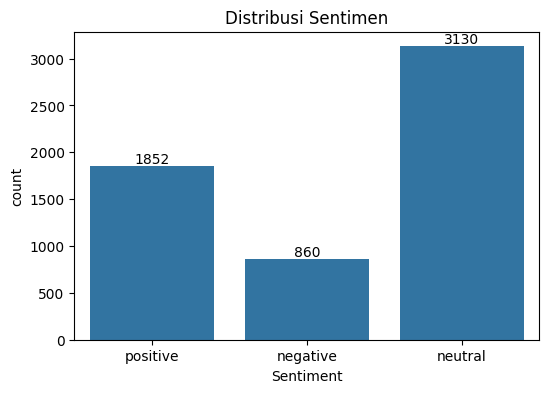

In [ ]:
# Visualisasi distribusi label
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)
plt.title("Distribusi Sentimen")

# Add count labels on each bar
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            f'{int(height)}',
            ha="center", va="bottom")
    
plt.show()

# print(df['Sentiment'].value_counts())

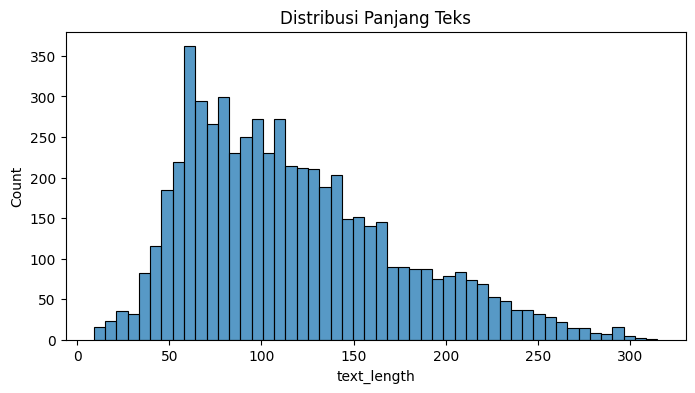

In [ ]:
df['text_length'] = df['Sentence'].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df['text_length'], bins=50)
plt.title("Distribusi Panjang Teks")
plt.show()

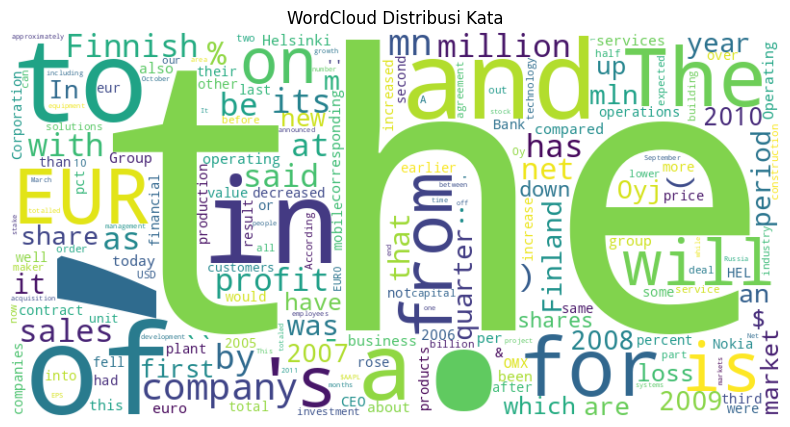

Jumlah kata unik: 15758


In [ ]:
# Word Frequency
from collections import Counter

all_words = ' '.join(df['Sentence']).split()
word_freq = Counter(all_words)

word_freq_df = pd.DataFrame(word_freq.most_common(), columns=['Word', 'Frequency'])

wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(word_freq)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Distribusi Kata")
plt.show()

print(f"Jumlah kata unik: {len(word_freq)}")
# word_freq.most_common(10)


# Pre Processing

In [ ]:
# lowercase
df['Sentence'] = df['Sentence'].str.lower()

In [ ]:
removed_log = []

# Remove URL, Mention, Angka, dan Simbol
def clean_text(text):
    # removed = re.findall(r"http\S+|@\w+|\d+", text)
    # removed_log.append(removed)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r"http\S+", "", text)      # remove URL
    text = re.sub(r"@\w+", "", text)         # remove mention
    text = re.sub(r"\d+", "", text)          # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()
    return text

df['Sentence'] = df['Sentence'].apply(clean_text)
# df['Removed'] = removed_log

In [ ]:
# Tokenization
df['tokens'] = df['Sentence'].apply(word_tokenize)
df.head()


,Sentence,Sentiment,text_length,tokens
0,the geosolutions technology will leverage bene...,positive,218,"[the, geosolutions, technology, will, leverage..."
1,$esi on lows down dollar_1 50 to dollar_2 50 b...,negative,55,"[$, esi, on, lows, down, dollar_1, 50, to, dol..."
2,for the last quarter of 2010 componenta s net ...,positive,193,"[for, the, last, quarter, of, 2010, componenta..."
3,according to the finnish russian chamber of co...,neutral,128,"[according, to, the, finnish, russian, chamber..."
4,the swedish buyout firm has sold its remaining...,neutral,135,"[the, swedish, buyout, firm, has, sold, its, r..."


In [ ]:
# Stopword Removal
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens'] = df['tokens'].apply(remove_stopwords)

In [ ]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens'] = df['tokens'].apply(lemmatize_words)

In [ ]:
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))
df.head()
# df[['text', 'clean_text']].head()

,Sentence,Sentiment,text_length,tokens,clean_text
0,the geosolutions technology will leverage bene...,positive,218,"[geosolutions, technology, leverage, benefon, ...",geosolutions technology leverage benefon gps s...
1,$esi on lows down dollar_1 50 to dollar_2 50 b...,negative,55,"[$, esi, low, dollar_1, 50, dollar_2, 50, bk, ...",$ esi low dollar_1 50 dollar_2 50 bk real poss...
2,for the last quarter of 2010 componenta s net ...,positive,193,"[last, quarter, 2010, componenta, net, sale, d...",last quarter 2010 componenta net sale doubled ...
3,according to the finnish russian chamber of co...,neutral,128,"[according, finnish, russian, chamber, commerc...",according finnish russian chamber commerce maj...
4,the swedish buyout firm has sold its remaining...,neutral,135,"[swedish, buyout, firm, sold, remaining, 22, 4...",swedish buyout firm sold remaining 22 4 percen...


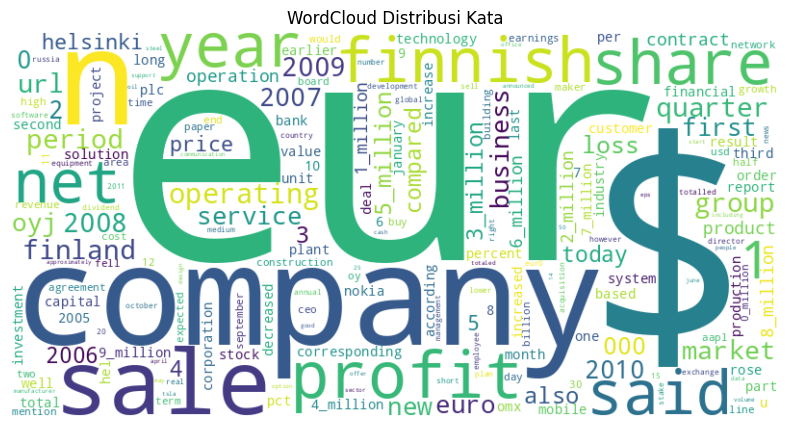

Jumlah kata unik: 10222


In [ ]:
# Word Frequency
from collections import Counter

all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

word_freq_df = pd.DataFrame(word_freq.most_common(), columns=['Word', 'Frequency'])

wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(word_freq)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Distribusi Kata")
# plt.savefig('wordcloud.png')
plt.show()

print(f"Jumlah kata unik: {len(word_freq)}")
# word_freq.most_common(10)


# Feature Extraction (TF-IDF)

In [ ]:
# df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))

tfidf = TfidfVectorizer(
    # max_features=len(word_freq),
    max_features=8000,
    min_df=6,
    max_df=0.7,
    ngram_range=(1, 3)
)

X = tfidf.fit_transform(df["clean_text"])
y = df["Sentiment"]

print("Shape TF-IDF:", X.shape)

Shape TF-IDF: (5842, 3081)


In [ ]:
# convert tfidf output back to a DataFrame
tfidf_df = pd.DataFrame(X.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df['Sentiment'] = y.values

# overall sparsity
total_cells = X.shape[0] * X.shape[1]
nnz = X.nnz
print(f"TF-IDF matrix sparsity: {nnz}/{total_cells} = {nnz/total_cells:.4%}\n")

# average tf-idf per sentiment
avg_tfidf = tfidf_df.groupby('Sentiment').mean()

# print top n features for each sentiment
top_n = 10
for sentiment in avg_tfidf.index:
    top_feats = avg_tfidf.loc[sentiment].sort_values(ascending=False).head(top_n)
    print(f"Top {top_n} features for '{sentiment}':")
    print(top_feats)
    print("-" * 40)

# inspect a few sample vectors
sample_idx = y.sample(5, random_state=42).index
print("\nSample TF-IDF vectors for some rows:")
display(tfidf_df.loc[sample_idx])

TF-IDF matrix sparsity: 69260/17999202 = 0.3848%

Top 10 features for 'negative':
eur          0.039964
url          0.025822
profit       0.023690
sale         0.020649
short        0.018349
year         0.018294
operating    0.015435
share        0.015076
loss         0.014368
quarter      0.014253
Name: negative, dtype: float64
----------------------------------------
Top 10 features for 'neutral':
company     0.026376
eur         0.023107
share       0.016997
finland     0.013864
sale        0.013577
said        0.013178
service     0.011798
business    0.011661
finnish     0.011562
market      0.011311
Name: neutral, dtype: float64
----------------------------------------
Top 10 features for 'positive':
eur        0.030129
url        0.024666
sale       0.020126
year       0.019430
company    0.016239
profit     0.015561
long       0.015246
said       0.014160
net        0.013859
buy        0.012317
Name: positive, dtype: float64
----------------------------------------

Sample TF

,00,000,000 corresponding,000 corresponding period,000 eur,000 euro,000 people,000 sq,000 square,000 square metre,...,zone,àland,àland report,àland report operating,ñinen,ñl,ñnnen,ñnnen tehtaat,ñrvi,Sentiment
4584,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,neutral
177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
167,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,negative
5585,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
2339,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,neutral


In [ ]:
tfidf_df["abp hel"].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: abp hel, dtype: float64

# Split Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# SMOTE

In [ ]:
print("Distribusi sebelum SMOTE:")
print(y_train.value_counts())

Distribusi sebelum SMOTE:
Sentiment
neutral     2504
positive    1481
negative     688
Name: count, dtype: int64


In [ ]:
smote = SMOTE(
    k_neighbors=10,
    sampling_strategy='auto',
    random_state=42
    )

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [ ]:
print("Distribusi setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Distribusi setelah SMOTE:
Sentiment
negative    2504
neutral     2504
positive    2504
Name: count, dtype: int64


In [ ]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 55312 stored elements and shape (4673, 3081)>

# Training Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

# rf.fit(X_train_smote, y_train_smote)

rf_hyperparams = {
    "n_estimators": [199],
    "max_depth": [70],
    "min_samples_split": [15],
    "min_samples_leaf": [2],
    "max_features": ["log2"],
    "class_weight": ["balanced_subsample"],
    "bootstrap": [False],
    "criterion": ["gini"],
}

rf_grid = RandomizedSearchCV(
    estimator=rf, 
    param_grid=rf_hyperparams, 
    cv=50, 
    n_jobs=-1, 
    verbose=2
)

rf_grid.fit(X_train_smote, y_train_smote)

Fitting 50 folds for each of 1 candidates, totalling 50 fits
[CV] END bootstrap=False, class_weight=balanced_subsample, criterion=gini, max_depth=70, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=199; total time=   2.3s
[CV] END bootstrap=False, class_weight=balanced_subsample, criterion=gini, max_depth=70, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=199; total time=   2.4s
[CV] END bootstrap=False, class_weight=balanced_subsample, criterion=gini, max_depth=70, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=199; total time=   2.4s
[CV] END bootstrap=False, class_weight=balanced_subsample, criterion=gini, max_depth=70, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=199; total time=   2.3s
[CV] END bootstrap=False, class_weight=balanced_subsample, criterion=gini, max_depth=70, max_features=log2, min_samples_leaf=2, min_samples_split=15, n_estimators=199; total time=   2.4s
[CV]

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'bootstrap': [False], 'class_weight': ['balanced_subsample'], 'criterion': ['gini'], 'max_depth': [70], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,50
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,199


In [ ]:
# best_rf = rf_grid.best_estimator_
# print("Best Hyperparameters:")
# rf_grid.best_params_

# Evaluasi

In [ ]:
# y_pred = rf_grid.predict(X_train_smote)

# print(classification_report(y_train_smote, y_pred))

# cm = confusion_matrix(y_train_smote, y_pred)
# print(cm)

In [ ]:
y_pred = rf_grid.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

    negative       0.37      0.44      0.40       172
     neutral       0.71      0.78      0.74       626
    positive       0.74      0.55      0.63       371

    accuracy                           0.66      1169
   macro avg       0.61      0.59      0.59      1169
weighted avg       0.67      0.66      0.66      1169

[[ 76  67  29]
 [ 95 488  43]
 [ 35 132 204]]


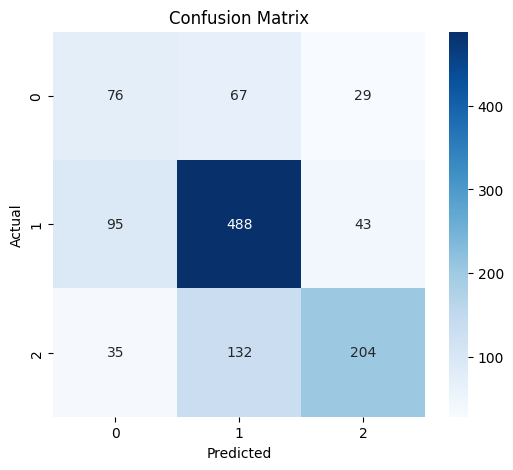

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
